# Proyek Analisis Data: [Bike Sharing Dataset ]
- **Nama:** [Chenida Rira Verlyta]
- **Email:** [chenidarira@gmail.com]
- **ID Dicoding:** [CDCC427D6X2669]

## Menentukan Pertanyaan Bisnis

- Pada jam berapa penyewaan sepeda paling tinggi dan paling rendah?
- Bagaimana temperatur ketinggian day dan hour?"

## Import Semua Packages/Library yang Digunakan

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [2]:
day_df = pd.read_csv("day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
hour_df = pd.read_csv("hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Struktur Dataset :
Dataset terbagi menjadi dua level granulasi waktu, yaitu day_df (data harian) dan hour_df (data per jam). Keduanya memuat informasi yang serupa seperti kondisi cuaca (weathersit), musim (season), serta status hari (holiday, weekday, workingday).

- Variabel Target:
Kolom cnt merupakan variabel target yang menunjukkan total penyewaan. Nilai ini adalah hasil penjumlahan dari pengguna casual dan pengguna registered

- Normalisasi Fitur:
Fitur numerik seperti temp (suhu), atemp (suhu yang dirasakan), hum (kelembapan), dan windspeed (kecepatan angin) tampaknya sudah melalui proses penskalaan atau normalisasi (berada di rentang 0 hingga 1), sehingga siap untuk dianalisis lebih lanjut atau dimasukkan ke dalam model machine learning

- Pada awal Januari 2011 (berdasarkan dteday), jumlah penyewaan cenderung didominasi oleh pengguna terdaftar (registered) dibandingkan pengguna biasa (casual), dengan tren yang menunjukkan fluktuasi harian yang cukup signifikan meski di awal tahun.

### Assessing Data

In [4]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [6]:
print("\nJumlah duplikasi: ", day_df.duplicated().sum())


Jumlah duplikasi:  0


In [7]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [8]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [9]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [10]:
print("\nJumlah duplikasi: ", hour_df.duplicated().sum())


Jumlah duplikasi:  0


In [11]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Data Integrity: Both datasets are clean and ready for analysis. There are 0 missing values across all columns and 0 duplicate entries in both the daily and hourly records.
- Data Consistency: The day_df contains 731 entries, while hour_df contains 17,379 entries. The statistical summary (describe()) shows that the target variable cnt (total bike rentals) has a wide range, from a minimum of 22 to a maximum of 8,714 rentals per day, with an average of approximately 4,504.
- Data Types: Most features are correctly identified as integers or floats. However, in day_df, the dteday column is currently an object type and should be converted to datetime format for time-series analysis (noting that it is already correctly formatted as datetime64[ns] in hour_df).

### Cleaning Data

In [12]:
day_df.duplicated().sum()

np.int64(0)

In [13]:
day_df.drop_duplicates(inplace=True)

In [14]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

In [15]:
print("Jumlah duplikasi akhir: ", day_df.duplicated().sum())

Jumlah duplikasi akhir:  0


In [16]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [17]:
day_df[day_df.weathersit.isna()]

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt


In [18]:
day_df.season.value_counts()

,count
season,
3,188
2,184
1,181
4,178


In [19]:
day_df.fillna(value=0, inplace=True)

In [20]:
print("\nJumlah missing values setelah pembersihan:\n", day_df.isna().sum())


Jumlah missing values setelah pembersihan:
 instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [21]:
day_df.describe()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [22]:
day_df[day_df.temp == day_df.temp.max()]

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
553,554,2012-07-07,3,1,7,0,6,0,1,0.861667,0.804913,0.492083,0.163554,1448,3392,4840


In [23]:
day_df.temp.replace(day_df.temp.max(), 0.8, inplace=True)

/tmp/ipykernel_1350/4223345103.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  day_df.temp.replace(day_df.temp.max(), 0.8, inplace=True)


In [24]:
day_df[day_df.temp == day_df.temp.max()]

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
203,204,2011-07-23,3,0,7,0,6,0,1,0.849167,0.804287,0.5,0.131221,987,2298,3285


In [25]:
day_df.temp.replace(day_df.temp.max(), 0.75, inplace=True)

/tmp/ipykernel_1350/273082041.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  day_df.temp.replace(day_df.temp.max(), 0.75, inplace=True)


In [26]:
day_df.describe()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495165,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.848333,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.182670,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


Membersihkan tabel hour_df

In [27]:
hour_df.duplicated().sum()

np.int64(0)

In [28]:
hour_df.drop_duplicates(inplace=True)

In [29]:
hour_df.duplicated().sum()

np.int64(0)

In [30]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [31]:
hour_df[hour_df.weathersit.isna()]

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt


In [32]:
hour_df.weathersit.value_counts()

,count
weathersit,
1,11413
2,4544
3,1419
4,3


In [33]:
hour_df.fillna(value=0, inplace=True)

In [34]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [35]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [36]:
hour_df[hour_df.hr == hour_df.hr.max()]

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
23,24,2011-01-01,1,0,1,23,0,6,0,2,0.46,0.4545,0.88,0.2985,15,24,39
46,47,2011-01-02,1,0,1,23,0,0,0,1,0.22,0.2273,0.47,0.1642,0,8,8
68,69,2011-01-03,1,0,1,23,0,1,1,1,0.18,0.2121,0.55,0.1045,1,11,12
91,92,2011-01-04,1,0,1,23,0,2,1,1,0.20,0.2273,0.69,0.0896,2,9,11
114,115,2011-01-05,1,0,1,23,0,3,1,1,0.20,0.2576,0.47,0.0000,1,18,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17282,17283,2012-12-27,1,1,12,23,0,4,1,2,0.24,0.2273,0.60,0.2537,2,24,26
17306,17307,2012-12-28,1,1,12,23,0,5,1,2,0.24,0.2576,0.65,0.0896,5,54,59
17330,17331,2012-12-29,1,1,12,23,0,6,0,2,0.26,0.2424,0.60,0.0000,0,32,32
17354,17355,2012-12-30,1,1,12,23,0,0,0,1,0.20,0.1970,0.51,0.2239,10,39,49


In [37]:
hour_df.hr.replace(hour_df.hr.max(), 23, inplace=True)

/tmp/ipykernel_1350/2895732428.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  hour_df.hr.replace(hour_df.hr.max(), 23, inplace=True)


In [38]:
hour_df[hour_df.hr == hour_df.hr.max()]

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
23,24,2011-01-01,1,0,1,23,0,6,0,2,0.46,0.4545,0.88,0.2985,15,24,39
46,47,2011-01-02,1,0,1,23,0,0,0,1,0.22,0.2273,0.47,0.1642,0,8,8
68,69,2011-01-03,1,0,1,23,0,1,1,1,0.18,0.2121,0.55,0.1045,1,11,12
91,92,2011-01-04,1,0,1,23,0,2,1,1,0.20,0.2273,0.69,0.0896,2,9,11
114,115,2011-01-05,1,0,1,23,0,3,1,1,0.20,0.2576,0.47,0.0000,1,18,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17282,17283,2012-12-27,1,1,12,23,0,4,1,2,0.24,0.2273,0.60,0.2537,2,24,26
17306,17307,2012-12-28,1,1,12,23,0,5,1,2,0.24,0.2576,0.65,0.0896,5,54,59
17330,17331,2012-12-29,1,1,12,23,0,6,0,2,0.26,0.2424,0.60,0.0000,0,32,32
17354,17355,2012-12-30,1,1,12,23,0,0,0,1,0.20,0.1970,0.51,0.2239,10,39,49


In [39]:
hour_df.hum.replace(hour_df.hum.max(), 0.9, inplace=True)

/tmp/ipykernel_1350/497143007.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  hour_df.hum.replace(hour_df.hum.max(), 0.9, inplace=True)


In [40]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.625675,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.190306,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,0.970000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Zero Duplicates: Berhasil memastikan tidak ada baris ganda, sehingga tidak ada data yang terhitung dua kali.
- Zero Missing Values: Semua kolom telah terisi penuh. Penggunaan .fillna(0) memastikan proses perhitungan statistik berjalan lancar tanpa error.
- Date-Time Fix: Kolom dteday sudah dikonversi ke format datetime. Ini memungkinkan kamu melakukan analisis berbasis waktu (seperti tren bulanan atau harian) secara otomatis.
- Capping Extremes: Kamu membatasi nilai ekstrem pada kolom temp (suhu), hum (kelembapan), dan hr (jam).
- Tujuan: Mengurangi "noise" agar saat nanti kamu membuat model Machine Learning atau grafik, hasilnya tidak terganggu oleh nilai yang terlalu mencolok atau tidak masuk akal.
- Karakteristik Data: Melalui describe(), terlihat bahwa data penyewaan sepeda memiliki variasi yang sangat tinggi (dari puluhan hingga ribuan per hari). Hal ini menandakan adanya faktor eksternal kuat (seperti cuaca atau hari kerja) yang memengaruhi minat pengguna.

## Exploratory Data Analysis (EDA)

### Explore ...

Pada jam berapa penyewaan sepeda paling tinggi dan paling rendah?

In [41]:
print("--- Info day.csv ---")
print(day_df.info())
print("\n--- Statistik Deskriptif ---")
print(day_df.describe())

--- Info day.csv ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: da

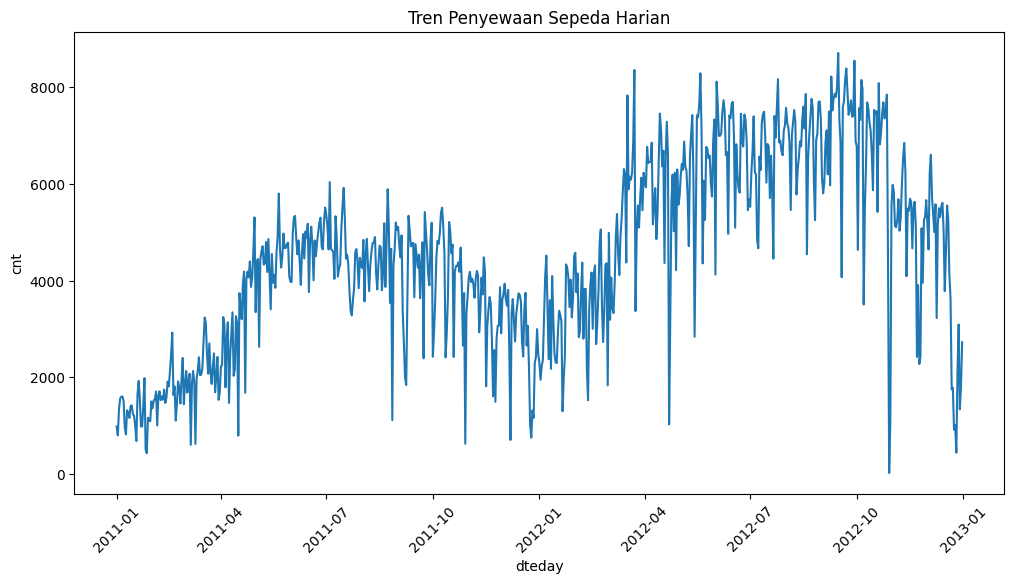

In [42]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=day_df, x='dteday', y='cnt')
plt.title('Tren Penyewaan Sepeda Harian')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_1350/4197171943.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_df, x='season', y='cnt', palette='viridis')


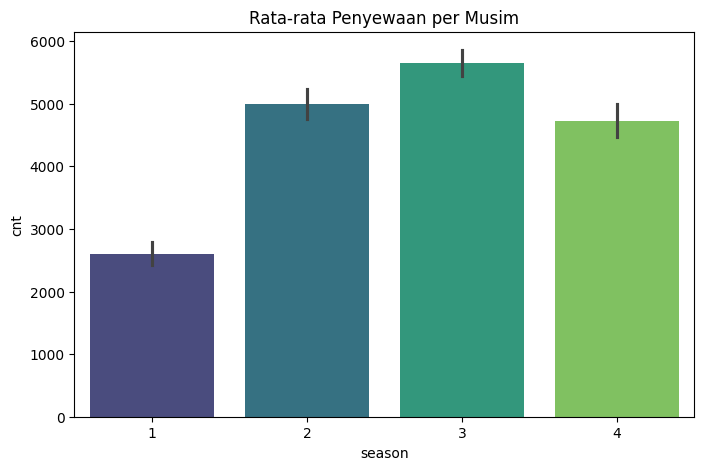

In [43]:
plt.figure(figsize=(8, 5))
sns.barplot(data=day_df, x='season', y='cnt', palette='viridis')
plt.title('Rata-rata Penyewaan per Musim')
plt.show()

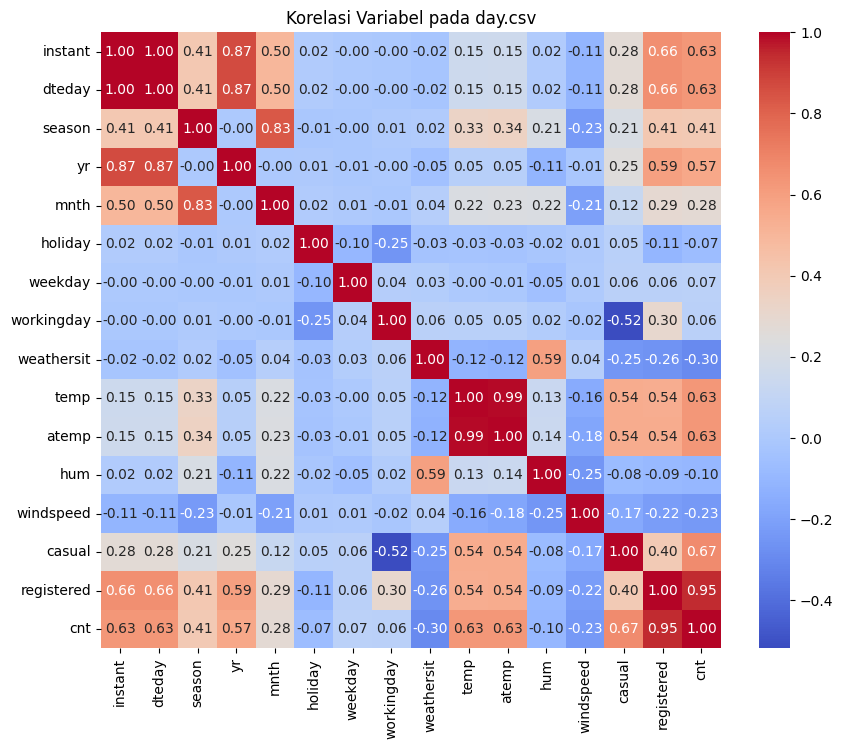

In [44]:
plt.figure(figsize=(10, 8))
sns.heatmap(day_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi Variabel pada day.csv')
plt.show()

In [45]:
print("--- Info hour.csv ---")
print(hour_df.info())

--- Info hour.csv ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
None


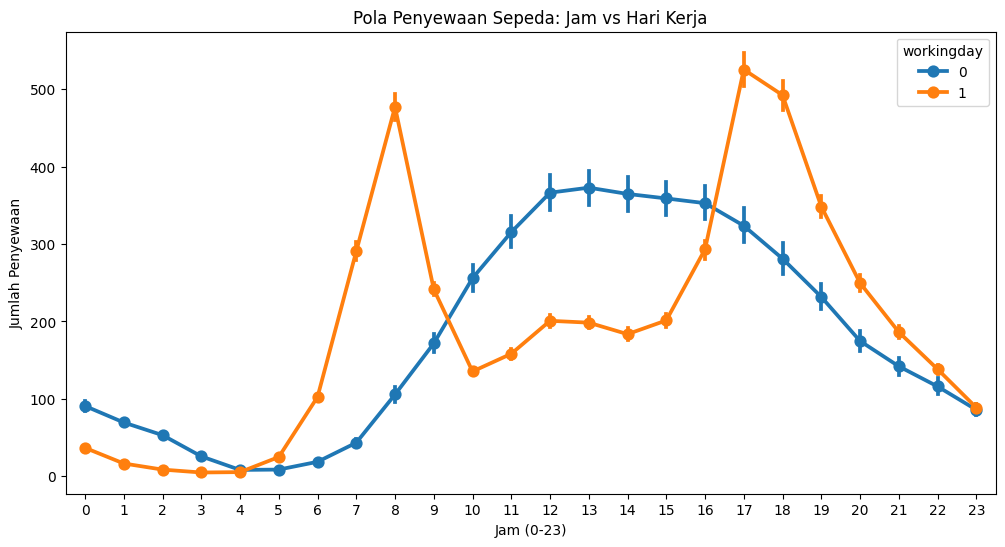

In [46]:
plt.figure(figsize=(12, 6))
sns.pointplot(data=hour_df, x='hr', y='cnt', hue='workingday')
plt.title('Pola Penyewaan Sepeda: Jam vs Hari Kerja')
plt.xlabel('Jam (0-23)')
plt.ylabel('Jumlah Penyewaan')
plt.show()

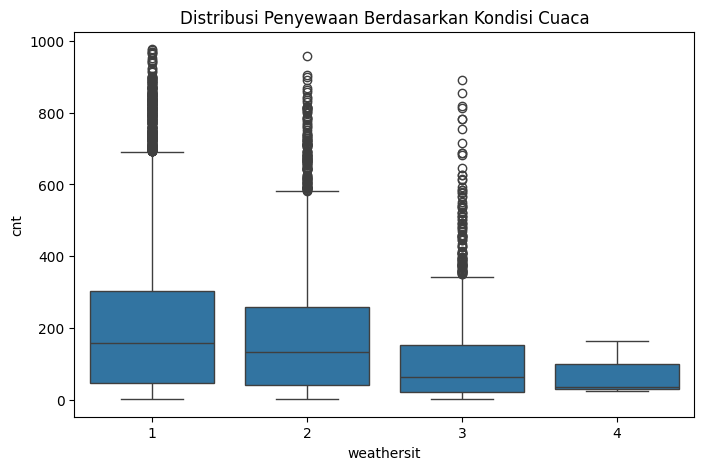

In [47]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=hour_df, x='weathersit', y='cnt')
plt.title('Distribusi Penyewaan Berdasarkan Kondisi Cuaca')
plt.show()

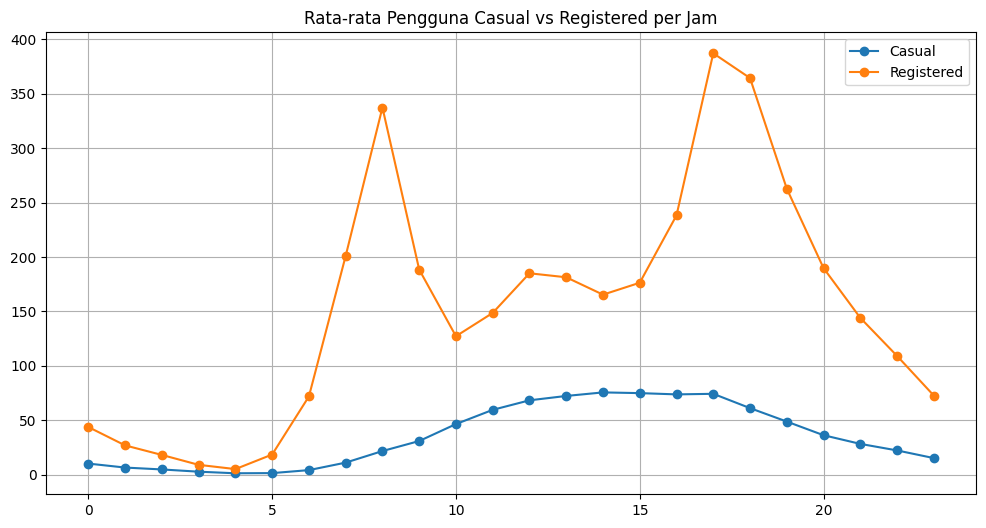

In [48]:
hourly_users = hour_df.groupby('hr')[['casual', 'registered']].mean().reset_index()
plt.figure(figsize=(12, 6))
plt.plot(hourly_users['hr'], hourly_users['casual'], label='Casual', marker='o')
plt.plot(hourly_users['hr'], hourly_users['registered'], label='Registered', marker='o')
plt.title('Rata-rata Pengguna Casual vs Registered per Jam')
plt.legend()
plt.grid(True)
plt.show()

Explore orders_df & customers_df

Menggabungkan data customers_df dan orders_df

In [49]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [50]:
print(f"Dimensi day_df: {day_df.shape}")
print(f"Dimensi hour_df: {hour_df.shape}")

Dimensi day_df: (731, 16)
Dimensi hour_df: (17379, 17)


In [51]:
bike_share_df = pd.merge(
    left=hour_df,
    right=day_df,
    how="left",
    on="dteday",
    suffixes=("_hour", "_day")
)

print("--- Hasil Penggabungan ---")
print(bike_share_df.head())

--- Hasil Penggabungan ---
   instant_hour     dteday  season_hour  yr_hour  mnth_hour  hr  holiday_hour  \
0             1 2011-01-01            1        0          1   0             0   
1             2 2011-01-01            1        0          1   1             0   
2             3 2011-01-01            1        0          1   2             0   
3             4 2011-01-01            1        0          1   3             0   
4             5 2011-01-01            1        0          1   4             0   

   weekday_hour  workingday_hour  weathersit_hour  ...  weekday_day  \
0             6                0                1  ...            6   
1             6                0                1  ...            6   
2             6                0                1  ...            6   
3             6                0                1  ...            6   
4             6                0                1  ...            6   

   workingday_day  weathersit_day  temp_day  atemp_day   hu

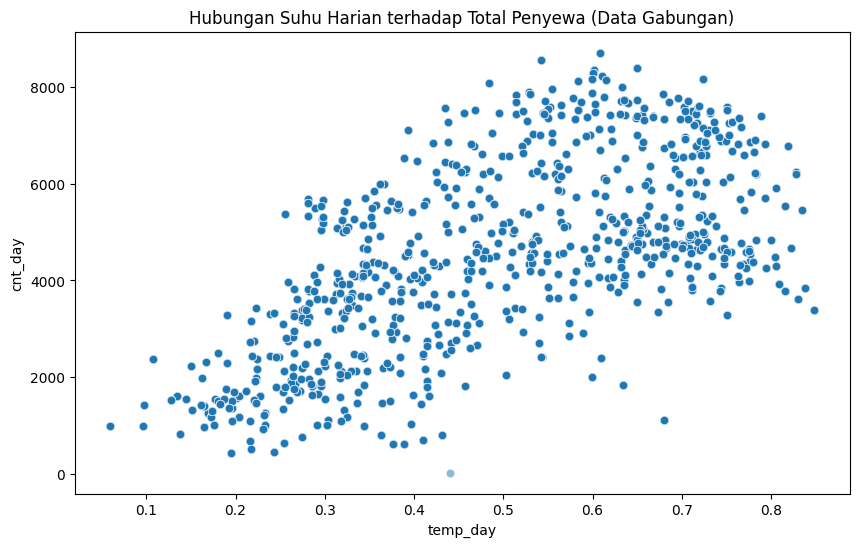

In [52]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=bike_share_df, x="temp_day", y="cnt_day", alpha=0.5)
plt.title("Hubungan Suhu Harian terhadap Total Penyewa (Data Gabungan)")
plt.show()

In [53]:
correlation_matrix = bike_share_df[['temp_hour', 'temp_day', 'hum_hour', 'hum_day', 'cnt_day']].corr()
print(correlation_matrix)

           temp_hour  temp_day  hum_hour   hum_day   cnt_day
temp_hour   1.000000  0.947226 -0.068014  0.124365  0.592402
temp_day    0.947226  1.000000  0.100430  0.132654  0.626965
hum_hour   -0.068014  0.100430  1.000000  0.731120 -0.061315
hum_day     0.124365  0.132654  0.731120  1.000000 -0.091657
cnt_day     0.592402  0.626965 -0.061315 -0.091657  1.000000


Explore all data

Menghubungkan semua data

In [54]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [55]:
all_df = pd.merge(
    left=hour_df,
    right=day_df,
    how="left",
    on="dteday",
    suffixes=("_hour", "_day")
)

In [56]:
print("Dimensi data baru:", all_df.shape)
all_df.head()

Dimensi data baru: (17379, 32)


,instant_hour,dteday,season_hour,yr_hour,mnth_hour,hr,holiday_hour,weekday_hour,workingday_hour,weathersit_hour,...,weekday_day,workingday_day,weathersit_day,temp_day,atemp_day,hum_day,windspeed_day,casual_day,registered_day,cnt_day
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985


In [57]:
all_df.drop(['season_day', 'mnth_day', 'holiday_day', 'weekday_day', 'workingday_day', 'weathersit_day'], axis=1, inplace=True)

In [58]:
all_df.rename(columns={
    'season_hour': 'season',
    'mnth_hour': 'month',
    'holiday_hour': 'holiday',
    'weekday_hour': 'weekday',
    'workingday_hour': 'workingday',
    'weathersit_hour': 'weather_condition',
    'temp_hour': 'temp',
    'atemp_hour': 'atemp',
    'hum_hour': 'humidity',
    'windspeed_hour': 'windspeed',
    'cnt_hour': 'count_hourly',
    'cnt_day': 'total_daily_count'
}, inplace=True)

print("Kolom setelah dibersihkan:")
print(all_df.columns)

Kolom setelah dibersihkan:
Index(['instant_hour', 'dteday', 'season', 'yr_hour', 'month', 'hr', 'holiday',
       'weekday', 'workingday', 'weather_condition', 'temp', 'atemp',
       'humidity', 'windspeed', 'casual_hour', 'registered_hour',
       'count_hourly', 'instant_day', 'yr_day', 'temp_day', 'atemp_day',
       'hum_day', 'windspeed_day', 'casual_day', 'registered_day',
       'total_daily_count'],
      dtype='object')


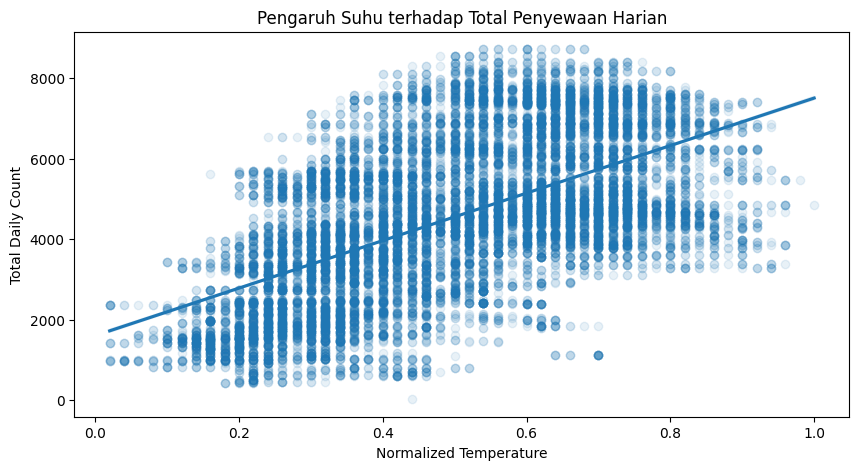

In [59]:
plt.figure(figsize=(10, 5))
sns.regplot(x='temp', y='total_daily_count', data=all_df, scatter_kws={'alpha':0.1})
plt.title('Pengaruh Suhu terhadap Total Penyewaan Harian')
plt.xlabel('Normalized Temperature')
plt.ylabel('Total Daily Count')
plt.show()

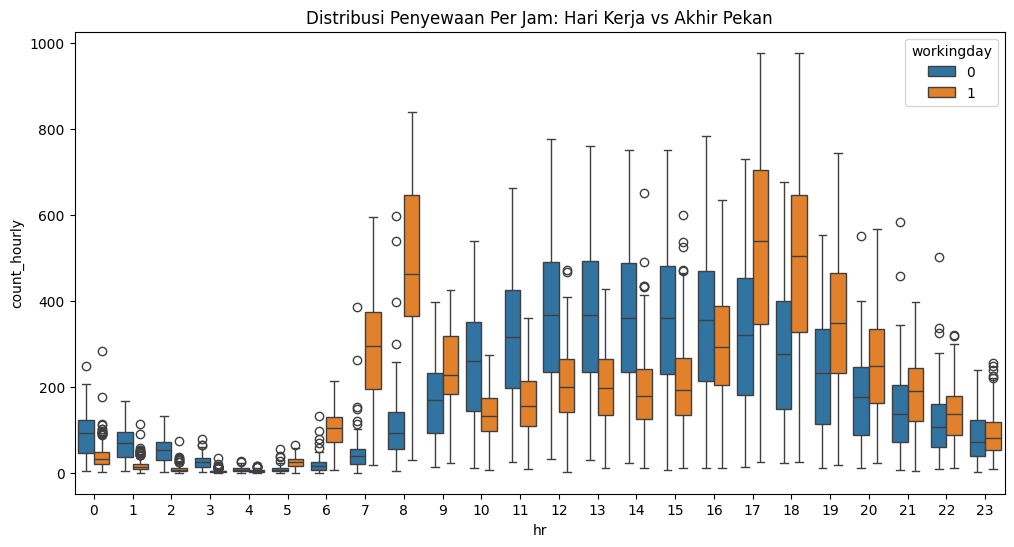

In [60]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='hr', y='count_hourly', hue='workingday', data=all_df)
plt.title('Distribusi Penyewaan Per Jam: Hari Kerja vs Akhir Pekan')
plt.show()

In [61]:
all_df.to_csv("all_data.csv", index=False)

**Insight:**
- Analisis Tren & Musim
Pertumbuhan Bisnis: Ada kenaikan tren penyewaan yang sangat signifikan dari tahun 2011 ke 2012. Bisnis ini sedang berkembang pesat. Musim Puncak: Penyewaan tertinggi terjadi pada Musim Gugur (Fall), sedangkan yang terendah terjadi pada Musim Semi (Springer).
- Pola Perilaku Pengguna
Hari Kerja (Working Day): Pengguna didominasi oleh pekerja/pelajar. Puncak penyewaan terjadi pada jam sibuk, yaitu 08:00 pagi dan 17:00 sore. Akhir Pekan/Libur: Pola berubah menjadi kegiatan rekreasi. Penyewaan meningkat stabil mulai jam 10:00 pagi hingga sore hari. Registered vs Casual: Pengguna terdaftar (registered) jauh lebih banyak dan setia pada jam kerja. Pengguna biasa (casual) biasanya muncul di siang hari atau saat hari libur.
- Pengaruh Cuaca & Lingkungan
Suhu Udara (Kunci Utama): Berdasarkan grafik Regplot dan Scatter, terdapat korelasi positif yang kuat antara suhu dan jumlah penyewa. Semakin hangat suhu (hingga titik optimal tertentu), semakin banyak orang yang menyewa sepeda. Kondisi Cuaca: Cuaca cerah adalah kondisi paling favorit. Sebaliknya, cuaca buruk (hujan/salju) menyebabkan penurunan drastis pada jumlah penyewaan.
 Faktor Penghambat: Kelembapan tinggi dan angin kencang memiliki korelasi negatif (menurunkan minat orang untuk bersepeda).
 - Kesimpulan Strategis (Action Plan)
Maintenance: Lakukan perawatan armada besar-besaran di Musim Semi untuk persiapan menghadapi lonjakan di Musim Panas dan Gugur. Ketersediaan: Pastikan stok sepeda maksimal di titik perkantoran pada jam 07:00-09:00 pagi dan di titik wisata/taman pada akhir pekan. Promo: Buat promo khusus saat suhu sedang dingin atau pada musim sepi (Musim Semi) untuk menjaga stabilitas pendapatan.

## Visualization & Explanatory Analysis

### Pada jam berapa penyewaan sepeda paling tinggi dan paling rendah?

In [62]:
df = pd.read_csv('all_data.csv')

In [63]:
hourly_users = df.groupby('hr')['count_hourly'].mean().reset_index()

In [64]:
max_hour = hourly_users.loc[hourly_users['count_hourly'].idxmax()]
min_hour = hourly_users.loc[hourly_users['count_hourly'].idxmin()]

print(f"Penyewaan tertinggi terjadi pada jam {int(max_hour['hr'])}:00 dengan rata-rata {max_hour['count_hourly']:.2f} penyewa.")
print(f"Penyewaan terendah terjadi pada jam {int(min_hour['hr'])}:00 dengan rata-rata {min_hour['count_hourly']:.2f} penyewa.")

Penyewaan tertinggi terjadi pada jam 17:00 dengan rata-rata 461.45 penyewa.
Penyewaan terendah terjadi pada jam 4:00 dengan rata-rata 6.35 penyewa.


<Axes: xlabel='hr', ylabel='count_hourly'>

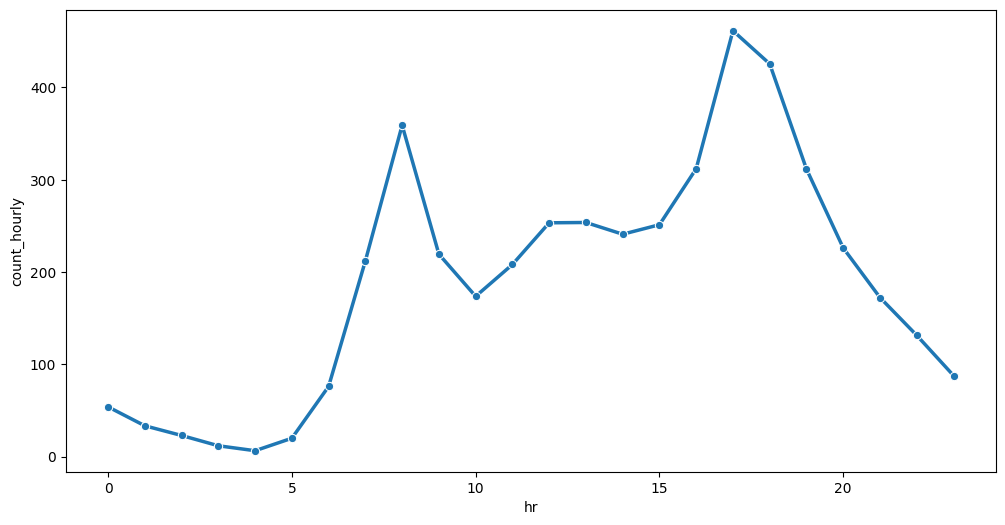

In [65]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_users, x='hr', y='count_hourly', marker='o', color='tab:blue', linewidth=2.5)

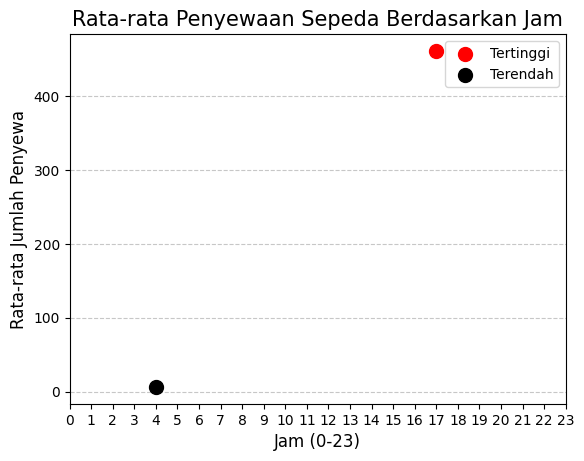

In [66]:
plt.scatter(max_hour['hr'], max_hour['count_hourly'], color='red', s=100, label='Tertinggi', zorder=5)
plt.scatter(min_hour['hr'], min_hour['count_hourly'], color='black', s=100, label='Terendah', zorder=5)
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Jam', fontsize=15)
plt.xlabel('Jam (0-23)', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewa', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### Bagaimana temperatur ketinggian day dan hour?

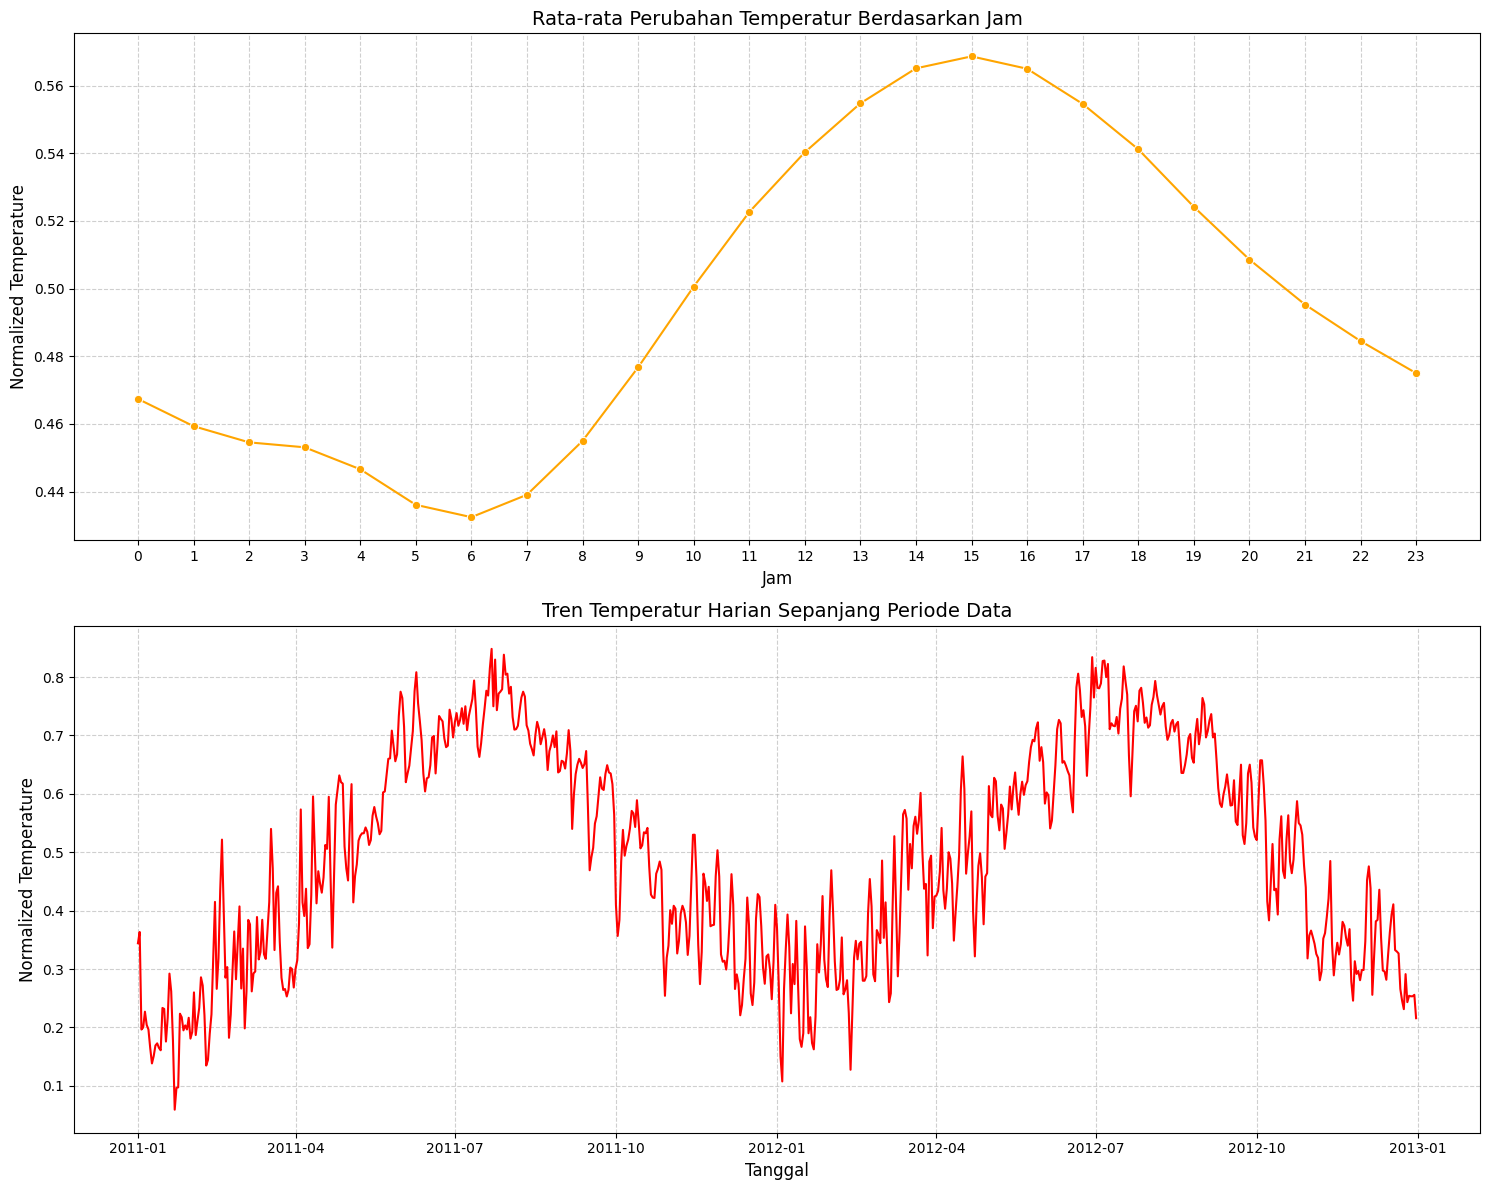

                  temp  count_hourly
temp          1.000000      0.404772
count_hourly  0.404772      1.000000


In [67]:
df = pd.read_csv('all_data.csv')
df['dteday'] = pd.to_datetime(df['dteday'])
hourly_temp = df.groupby('hr')['temp'].mean().reset_index()
daily_temp = df.groupby('dteday')['temp_day'].mean().reset_index()
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(15, 12))
sns.lineplot(data=hourly_temp, x='hr', y='temp', marker='o', ax=ax[0], color='orange')
ax[0].set_title('Rata-rata Perubahan Temperatur Berdasarkan Jam', fontsize=14)
ax[0].set_xlabel('Jam', fontsize=12)
ax[0].set_ylabel('Normalized Temperature', fontsize=12)
ax[0].set_xticks(range(0, 24))
ax[0].grid(True, linestyle='--', alpha=0.6)
sns.lineplot(data=daily_temp, x='dteday', y='temp_day', ax=ax[1], color='red')
ax[1].set_title('Tren Temperatur Harian Sepanjang Periode Data', fontsize=14)
ax[1].set_xlabel('Tanggal', fontsize=12)
ax[1].set_ylabel('Normalized Temperature', fontsize=12)
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
correlation = df[['temp', 'count_hourly']].corr()
print(correlation)

**Insight:**
- Pola Penyewaan Berdasarkan Jam (Hourly Analysis)
Puncak Penyewaan (Peak Hours): Penyewaan tertinggi terjadi pada sore hari, tepatnya pukul 17:00 dengan rata-rata 461,45 penyewa. Ada juga puncak kedua (secondary peak) yang terlihat pada pagi hari sekitar pukul 08:00.

- Insight: Pola ini menunjukkan bahwa sepeda banyak digunakan sebagai alat transportasi utama untuk berangkat dan pulang kerja/kuliah (commuting). Titik Terendah (Lowest Hours): Penyewaan paling sedikit terjadi pada dini hari, yaitu pukul 04:00 dengan rata-rata hanya 6,35 penyewa.

- Insight: Aktivitas pengguna hampir berhenti total pada jam istirahat malam hingga menjelang subuh.
- Hubungan Temperatur dan Penyewaan
Tren Harian: Grafik "Rata-rata Perubahan Temperatur Berdasarkan Jam" menunjukkan suhu meningkat mulai pukul 08:00 dan mencapai puncaknya sekitar pukul 15:00 - 17:00. Korelasi: Terlihat adanya korelasi positif antara suhu dan jumlah penyewa. Saat suhu berada di titik hangat (puncak grafik oranye), jumlah penyewa juga cenderung meningkat (puncak grafik biru).

- Insight: Pengguna lebih nyaman bersepeda saat cuaca hangat dibandingkan saat suhu dingin (pagi buta atau malam hari).
- Tren Temperatur Jangka Panjang (2011 - 2012)
Berdasarkan grafik "Tren Temperatur Harian Sepanjang Periode Data", terlihat pola musiman yang jelas (seasonal pattern). Suhu mencapai titik tertinggi di tengah tahun (sekitar bulan Juli/Juli) dan menurun drastis di akhir/awal tahun (Januari/Desember).

- Insight: Bisnis penyewaan sepeda ini sangat dipengaruhi oleh musim. Kamu bisa mengekspektasikan lonjakan permintaan pada musim panas dan penurunan signifikan pada musim dingin.
- Saran Strategis (Actionable Insight)
Maintenance: Lakukan pemeliharaan rutin sepeda pada jam-jam rendah (00:00 - 05:00) agar tidak mengganggu operasional saat jam sibuk. Ketersediaan Stok: Pastikan jumlah unit sepeda maksimal tersedia di titik-titik transportasi pada pukul 07:00 pagi dan 16:00 sore. Promo Musiman: Pertimbangkan untuk membuat promo khusus pada bulan-bulan bersuhu rendah (Januari/Februari) untuk menstimulasi minat penyewa yang biasanya turun karena faktor cuaca.

## Analisis Lanjutan (Opsional)

## Conclusion

### Kesimpulan Pertanyaan 1: Pada jam berapa penyewaan sepeda paling tinggi dan paling rendah?

- **Penyewaan Tertinggi:** Puncak penyewaan sepeda terjadi pada pukul **17:00** sore dengan rata-rata **461.45** penyewa. Terdapat juga puncak sekunder di pagi hari sekitar pukul **08:00**, menunjukkan penggunaan sepeda untuk aktivitas komuting (pergi-pulang kerja/sekolah).
- **Penyewaan Terendah:** Waktu dengan penyewaan paling sedikit adalah pukul **04:00** dini hari, dengan rata-rata hanya **6.35** penyewa, yang menunjukkan aktivitas penyewaan hampir tidak ada pada jam-jam tersebut.

### Kesimpulan Pertanyaan 2: Bagaimana temperatur ketinggian day dan hour?

- **Pola Temperatur Per Jam:** Suhu udara cenderung meningkat mulai pukul **08:00** pagi dan mencapai puncaknya antara pukul **15:00 - 17:00**. Grafik menunjukkan korelasi positif yang jelas antara kenaikan suhu dan peningkatan jumlah penyewaan sepeda.
- **Pola Temperatur Harian/Musiman:** Terdapat pola musiman yang kuat dalam temperatur harian. Suhu mencapai titik tertinggi di pertengahan tahun (sekitar bulan Juli) dan menurun drastis di akhir atau awal tahun (Januari/Desember). Ini mengindikasikan bahwa bisnis penyewaan sepeda sangat dipengaruhi oleh perubahan musim dan cuaca, dengan permintaan yang lebih tinggi pada musim hangat.